In [34]:

from pathlib import Path
path = Path('../us-patent-phrase-to-phrase-matching')

In [35]:
path

PosixPath('../us-patent-phrase-to-phrase-matching')

In [36]:
import pandas as pd

In [37]:
df = pd.read_csv(path/'train.csv')

In [38]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [39]:
df.describe(include='object')

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [40]:
df['input'] = 'TEXT1: ' + df.context + '; TEXT2: ' + df.target + '; ANC1: ' + df.anchor

In [41]:
df.input.tail()

36468    TEXT1: B44; TEXT2: wooden article; ANC1: wood ...
36469    TEXT1: B44; TEXT2: wooden box; ANC1: wood article
36470    TEXT1: B44; TEXT2: wooden handle; ANC1: wood a...
36471    TEXT1: B44; TEXT2: wooden material; ANC1: wood...
36472    TEXT1: B44; TEXT2: wooden substrate; ANC1: woo...
Name: input, dtype: object

In [42]:
from datasets import Dataset,DatasetDict

ds = Dataset.from_pandas(df)

In [43]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

In [44]:
model_nm = 'bert-base-uncased'

In [87]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

In [88]:
tokz.tokenize("G'day folks, I'm Jeremy from fast.ai!")

['g',
 "'",
 'day',
 'folks',
 ',',
 'i',
 "'",
 'm',
 'jeremy',
 'from',
 'fast',
 '.',
 'ai',
 '!']

In [47]:
tokz.tokenize("A platypus is an ornithorhynchus anatinus.")

['a',
 'pl',
 '##at',
 '##yp',
 '##us',
 'is',
 'an',
 'or',
 '##ni',
 '##thor',
 '##hy',
 '##nch',
 '##us',
 'ana',
 '##tin',
 '##us',
 '.']

In [48]:
def tok_func(x): return tokz(x["input"])


In [49]:
tok_ds = ds.map(tok_func, batched=True)


Map: 100%|██████████| 36473/36473 [00:00<00:00, 104991.46 examples/s]


In [50]:
row = tok_ds[0]
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 [101,
  3793,
  2487,
  1024,
  1037,
  22610,
  1025,
  3793,
  2475,
  1024,
  19557,
  18532,
  4765,
  1997,
  10796,
  1025,
  2019,
  2278,
  2487,
  1024,
  19557,
  18532,
  4765,
  102])

In [51]:
tokz.vocab['of']

1997

In [52]:
tok_ds = tok_ds.rename_columns({'score':'labels'})

In [53]:
eval_df = pd.read_csv(path/'test.csv')
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


In [54]:
dds = tok_ds.train_test_split(0.25, seed=42)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

In [55]:
eval_df['input'] = 'TEXT1: ' + eval_df.context + '; TEXT2: ' + eval_df.target + '; ANC1: ' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)
eval_ds

Map: 100%|██████████| 36/36 [00:00<00:00, 8101.02 examples/s]


Dataset({
    features: ['id', 'anchor', 'target', 'context', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 36
})

In [56]:
housing = pd.read_csv('../input/housing/housing.csv')
housing.head()

FileNotFoundError: [Errno 2] No such file or directory: '../input/housing/housing.csv'

In [57]:
def f(x): return -3*x**2 + 2*x + 20

In [58]:
f(1)

19

In [60]:
import numpy as np, matplotlib.pyplot as plt

def plot_function(f, min=-2.1, max=2.1, color='r'):
    x = np.linspace(min,max, 100)[:,None]
    plt.plot(x, f(x), color)

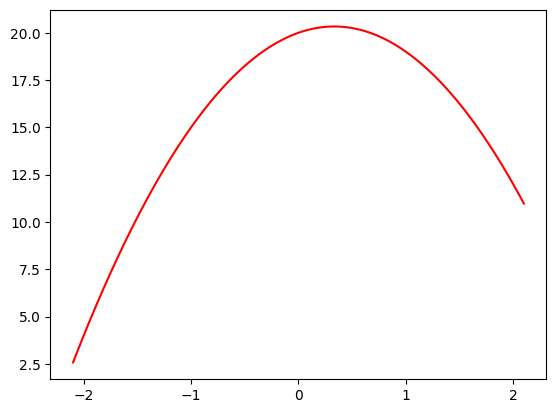

In [61]:
plot_function(f)

In [62]:
from numpy.random import normal,seed,uniform
np.random.seed(42)
print(np.random.normal(1,2,3))

[1.99342831 0.7234714  2.29537708]


In [63]:
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

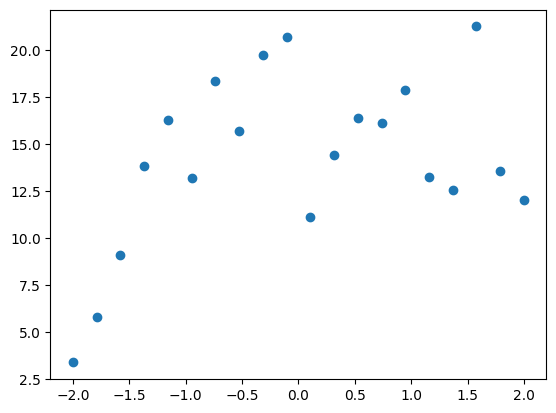

In [64]:
x = np.linspace(-2, 2, num=20)[:,None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y);

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x,y)
    plot_function(model.predict)

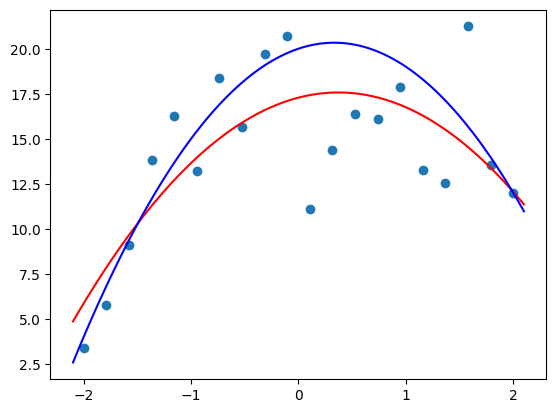

In [66]:
plot_poly(2)
plot_function(f, color='b')

In [67]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


In [68]:
np.set_printoptions(precision=2, suppress=True)
np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])

In [69]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)

array([[1.  , 0.68],
       [0.68, 1.  ]])

In [70]:
def corr(x,y): return np.corrcoef(x,y)[0][1]
corr(housing.MedInc, housing.MedHouseVal)

np.float64(0.6760250732906002)

In [72]:
def show_corr(df, a, b):
    x,y = df[a],df[b]
    plt.scatter(x,y, alpha=0.5, s=4)
    plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

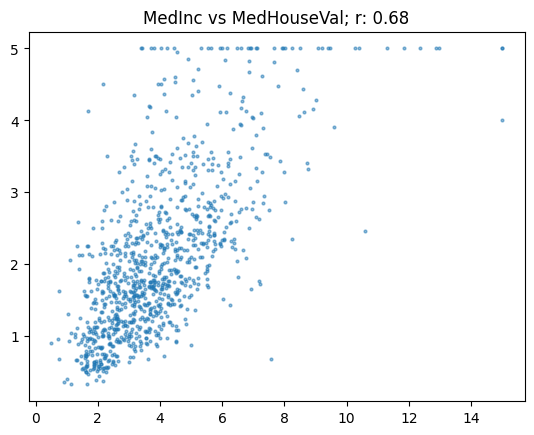

In [73]:
show_corr(housing, 'MedInc', 'MedHouseVal')

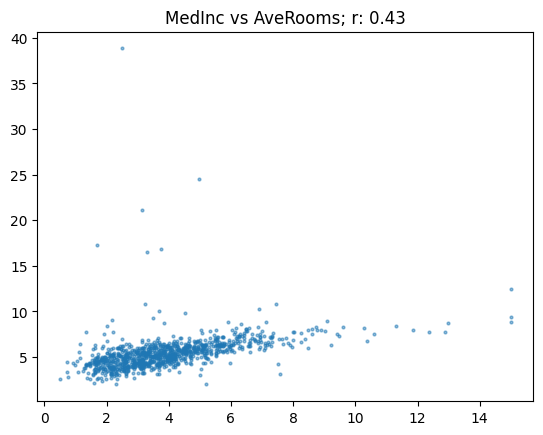

In [74]:
show_corr(housing, 'MedInc', 'AveRooms')


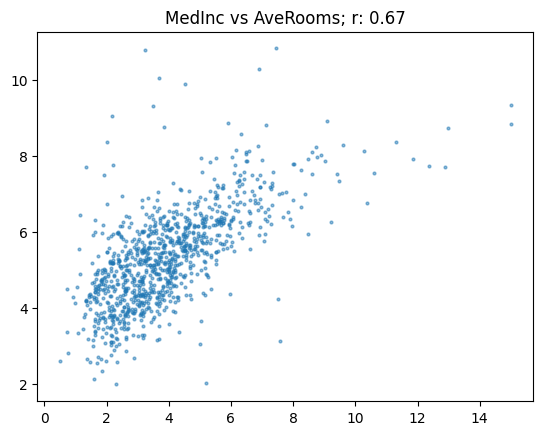

In [75]:

subset = housing[housing.AveRooms<12]
show_corr(subset, 'MedInc', 'AveRooms')

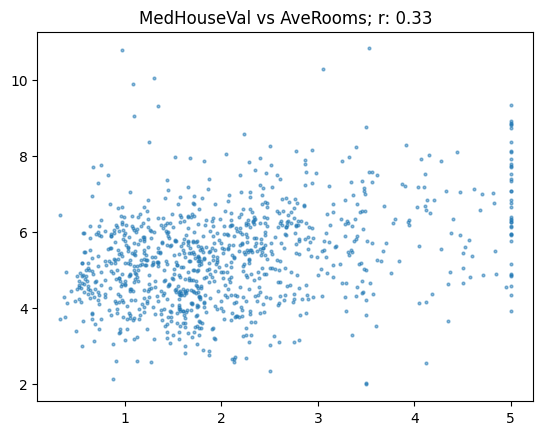

In [76]:
show_corr(subset, 'MedHouseVal', 'AveRooms')


In [94]:
import numpy as np
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}
eval_ds['id']

['4112d61851461f60',
 '09e418c93a776564',
 '36baf228038e314b',
 '1f37ead645e7f0c8',
 '71a5b6ad068d531f',
 '474c874d0c07bd21',
 '442c114ed5c4e3c9',
 'b8ae62ea5e1d8bdb',
 'faaddaf8fcba8a3f',
 'ae0262c02566d2ce',
 'a8808e31641e856d',
 '16ae4b99d3601e60',
 '25c555ca3d5a2092',
 '5203a36c501f1b7c',
 'b9fdc772bb8fd61c',
 '7aa5908a77a7ec24',
 'd19ef3979396d47e',
 'fd83613b7843f5e1',
 '2a619016908bfa45',
 '733979d75f59770d',
 '6546846df17f9800',
 '3ff0e7a35015be69',
 '12ca31f018a2e2b9',
 '03ba802ed4029e4d',
 'c404f8b378cbb008',
 '78243984c02a72e4',
 'de51114bc0faec3e',
 '7e3aff857f056bf9',
 '26c3c6dc6174b589',
 'b892011ab2e2cabc',
 '8247ff562ca185cc',
 'c057aecbba832387',
 '9f2279ce667b21dc',
 'b9ea2b06a878df6f',
 '79795133c30ef097',
 '25522ee5411e63e9']

In [78]:
from transformers import TrainingArguments,Trainer


In [79]:
bs = 64
epochs = 4

In [80]:
lr = 8e-5

In [82]:
args = TrainingArguments(
    'outputs',
    learning_rate=lr,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    evaluation_strategy="epoch",
    per_device_train_batch_size=bs,
    per_device_eval_batch_size=bs*2,
    num_train_epochs=epochs,
    weight_decay=0.01,
    report_to='none'
)

In [89]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=1)
trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],
                  tokenizer=tokz, compute_metrics=corr_d)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/3l/3ghlx2bn71xghsg_zzlqc8880000gn/T/ipykernel_3883/461981795.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],


In [90]:
trainer.train();

Epoch,Training Loss,Validation Loss


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 9119

In [91]:
preds = trainer.predict(eval_ds).predictions.astype(float)
preds

array([[ 0.42],
       [ 0.63],
       [ 0.41],
       [ 0.4 ],
       [ 0.45],
       [ 0.43],
       [ 0.54],
       [-0.02],
       [ 0.43],
       [ 0.89],
       [ 0.48],
       [ 0.39],
       [ 0.76],
       [ 0.91],
       [ 1.19],
       [ 0.41],
       [ 0.36],
       [ 0.22],
       [ 0.52],
       [ 0.34],
       [ 0.39],
       [ 0.33],
       [ 0.34],
       [ 0.31],
       [ 0.55],
       [-0.02],
       [-0.06],
       [-0.02],
       [-0.  ],
       [ 0.72],
       [ 0.42],
       [-0.  ],
       [ 0.73],
       [ 0.47],
       [ 0.41],
       [ 0.25]])

In [92]:
preds = np.clip(preds, 0, 1)

In [93]:
preds

array([[0.42],
       [0.63],
       [0.41],
       [0.4 ],
       [0.45],
       [0.43],
       [0.54],
       [0.  ],
       [0.43],
       [0.89],
       [0.48],
       [0.39],
       [0.76],
       [0.91],
       [1.  ],
       [0.41],
       [0.36],
       [0.22],
       [0.52],
       [0.34],
       [0.39],
       [0.33],
       [0.34],
       [0.31],
       [0.55],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.72],
       [0.42],
       [0.  ],
       [0.73],
       [0.47],
       [0.41],
       [0.25]])

In [95]:
import datasets

submission = datasets.Dataset.from_dict({
    'id': eval_ds['id'],
    'score': preds
})

submission.to_csv('submission.csv', index=False)

Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 193.72ba/s]


858